# Notebook 03 — Canny Edge Detection with Grayscale ROI

**Pipeline:** Adaptive Classical Vision Pipeline for Cut-Edge Detection  
**Step 3:** approximate rubber ROI → Canny on rectified grayscale image

**Input:** rectified images from `outputs/02_rectified_clean/`  
**Output:** binary edge maps saved to `outputs/03_canny/`

## Main idea
The previous version applied Canny directly on the binary mask. That was too restrictive because the thresholding step could lose thin gaps/cuts between rubber pieces.

This cleaner version uses the rubber mask only as a **coarse region of interest (ROI)**. The actual Canny detector is applied to the **rectified grayscale image**, restricted to that ROI. This makes the detector more sensitive to cut edges that are visible in grayscale but not perfectly separated by binarization.

## 1. Imports and configuration

In [1]:
!pip install opencv-python numpy matplotlib

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path

In [3]:
# ── Paths ──────────────────────────────────────────────────────────────────
RECTIFIED_DIR = Path("outputs/02_rectified")
CALIB_PATH    = RECTIFIED_DIR / "calibration.json"

OUTPUT_DIR = Path("outputs/03_canny")
DEBUG_DIR  = OUTPUT_DIR / "debug"

STEPS_DEBUG_DIR       = DEBUG_DIR / "steps_overview"
RAW_MASKS_DEBUG_DIR   = DEBUG_DIR / "raw_masks"
CLEAN_MASKS_DEBUG_DIR = DEBUG_DIR / "clean_masks"
ROI_DEBUG_DIR         = DEBUG_DIR / "rubber_roi"
EDGES_OVERLAY_DIR     = DEBUG_DIR / "edges_overlay"
DIAGNOSTICS_DIR       = DEBUG_DIR / "diagnostics"

for d in [
    OUTPUT_DIR,
    DEBUG_DIR,
    STEPS_DEBUG_DIR,
    RAW_MASKS_DEBUG_DIR,
    CLEAN_MASKS_DEBUG_DIR,
    ROI_DEBUG_DIR,
    EDGES_OVERLAY_DIR,
    DIAGNOSTICS_DIR,
]:
    d.mkdir(parents=True, exist_ok=True)

# ── Coarse rubber segmentation parameters ─────────────────────────────────
# The mask is NOT the final detection. It is only used to define where Canny
# should search for edges.
INTENSITY_THR = None       # None = Otsu threshold. Use fixed int if needed.
MASK_OTSU_FACTOR = 1.0     # 1.0 = pure Otsu. Lower values make rubber mask stricter.

# Remove small dark connected components from the mask, such as QR codes or noise.
MIN_RUBBER_COMPONENT_AREA_RATIO = 0.005

# Optional opening to remove small isolated noise. Use 0 to disable.
MASK_OPEN_KERNEL_SIZE = 0

# Dilation of the rubber mask to include cuts/gaps and borders around rubber.
ROI_DILATE_KERNEL_SIZE = 25

# ── Edge detection parameters ──────────────────────────────────────────────
# "gray_roi" = Canny on grayscale image restricted to rubber ROI.
# "mask"     = old behavior: Canny on binary mask.
# "combined" = union of both.
EDGE_SOURCE = "gray_roi"

# Blur before grayscale Canny. Increase to suppress rubber texture.
GRAY_CANNY_BLUR_KERNEL = (9, 9)

# Adaptive thresholds for grayscale Canny. If both are None, thresholds are
# computed from median intensity inside the ROI.
CANNY_T_LOW  = None
CANNY_T_HIGH = None
ADAPTIVE_CANNY_SIGMA = 0.3

# Fixed thresholds used only when EDGE_SOURCE is "mask" or in the mask part
# of "combined".
MASK_CANNY_T_LOW  = 50
MASK_CANNY_T_HIGH = 150

# ── Load calibration metadata ──────────────────────────────────────────────
with open(CALIB_PATH, "r") as f:
    calibration_data = json.load(f)

print(f"Rectified dir : {RECTIFIED_DIR.resolve()}")
print(f"Output dir    : {OUTPUT_DIR.resolve()}")
print(f"Debug dir     : {DEBUG_DIR.resolve()}")

Rectified dir : C:\Users\david\OneDrive\Documentos\UNI\VISION ARTIFICIAL\VA_RetoMichelin\models\David\outputs\02_rectified
Output dir    : C:\Users\david\OneDrive\Documentos\UNI\VISION ARTIFICIAL\VA_RetoMichelin\models\David\outputs\03_canny
Debug dir     : C:\Users\david\OneDrive\Documentos\UNI\VISION ARTIFICIAL\VA_RetoMichelin\models\David\outputs\03_canny\debug


## 2. Image list from calibration file

The notebook processes only the images included in `calibration.json`, avoiding debug images or figures being interpreted as dataset images.

In [4]:
def get_image_names_from_calibration(calibration_data) -> list[str]:
    """
    Robustly extract image names from calibration.json.
    Supports either:
      - dict keyed by image name
      - list of dicts with 'image_name'
    """
    if isinstance(calibration_data, dict):
        # Common format: {"Multimedia_31.jpg": {...}, ...}
        possible_names = [k for k in calibration_data.keys() if isinstance(k, str)]
        image_names = [n for n in possible_names if n.lower().endswith((".jpg", ".jpeg", ".png"))]
        if image_names:
            return sorted(image_names)

        # Alternative format: {"images": [{"image_name": ...}, ...]}
        if "images" in calibration_data and isinstance(calibration_data["images"], list):
            return sorted([
                item["image_name"]
                for item in calibration_data["images"]
                if isinstance(item, dict) and "image_name" in item
            ])

    if isinstance(calibration_data, list):
        return sorted([
            item["image_name"]
            for item in calibration_data
            if isinstance(item, dict) and "image_name" in item
        ])

    # Fallback: scan rectified folder for dataset images only.
    return sorted([
        p.name for p in RECTIFIED_DIR.iterdir()
        if p.suffix.lower() in {".jpg", ".jpeg", ".png"}
        and p.name.startswith("Multimedia_")
    ])


image_names = get_image_names_from_calibration(calibration_data)
print(f"Images to process: {len(image_names)}")
print(image_names[:5], "..." if len(image_names) > 5 else "")

Images to process: 20
['Multimedia_31.jpg', 'Multimedia_32.jpg', 'Multimedia_33.jpg', 'Multimedia_34.jpg', 'Multimedia_35.jpg'] ...


## 3. Coarse rubber mask

This mask is only used to define the search area for Canny. It does not need to perfectly separate every cut or gap.

In [5]:
def remove_small_components(mask: np.ndarray, min_area_ratio: float) -> np.ndarray:
    """
    Remove small connected components from a binary mask.
    This helps remove QR codes and isolated dark noise from the rubber ROI.
    """
    binary = (mask > 0).astype(np.uint8)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)

    min_area = mask.shape[0] * mask.shape[1] * min_area_ratio
    filtered = np.zeros_like(mask)

    for label in range(1, num_labels):
        area = stats[label, cv2.CC_STAT_AREA]
        if area >= min_area:
            filtered[labels == label] = 255

    return filtered


def segment_rubber_band_debug(img_gray: np.ndarray) -> dict:
    """
    Build a coarse rubber mask and keep intermediate stages for debugging.

    Returns
    -------
    dict with:
      - threshold
      - binary_bg
      - raw_mask
      - component_mask
      - clean_mask
    """
    if INTENSITY_THR is None:
        thr_otsu, _ = cv2.threshold(
            img_gray,
            0,
            255,
            cv2.THRESH_BINARY + cv2.THRESH_OTSU
        )
        thr = float(thr_otsu * MASK_OTSU_FACTOR)
    else:
        thr = float(INTENSITY_THR)

    _, binary_bg = cv2.threshold(
        img_gray,
        thr,
        255,
        cv2.THRESH_BINARY
    )

    # Rubber is dark, so after inversion rubber becomes white.
    raw_mask = cv2.bitwise_not(binary_bg)

    component_mask = remove_small_components(
        raw_mask,
        MIN_RUBBER_COMPONENT_AREA_RATIO
    )

    if MASK_OPEN_KERNEL_SIZE and MASK_OPEN_KERNEL_SIZE > 1:
        kernel = cv2.getStructuringElement(
            cv2.MORPH_ELLIPSE,
            (MASK_OPEN_KERNEL_SIZE, MASK_OPEN_KERNEL_SIZE)
        )
        clean_mask = cv2.morphologyEx(component_mask, cv2.MORPH_OPEN, kernel)
    else:
        clean_mask = component_mask.copy()

    return {
        "threshold": float(thr),
        "binary_bg": binary_bg,
        "raw_mask": raw_mask,
        "component_mask": component_mask,
        "clean_mask": clean_mask,
    }


def segment_rubber_band(img_gray: np.ndarray) -> tuple[np.ndarray, float]:
    """
    Compatibility wrapper.
    """
    stages = segment_rubber_band_debug(img_gray)
    return stages["clean_mask"], stages["threshold"]

## 4. Canny on grayscale ROI

The ROI is obtained by dilating the coarse rubber mask. This includes rubber borders and thin gaps around rubber pieces, even if those gaps were not perfectly segmented by thresholding.

In [6]:
def build_rubber_roi(mask: np.ndarray) -> np.ndarray:
    """
    Dilate the coarse rubber mask to build a search area for edge detection.
    """
    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (ROI_DILATE_KERNEL_SIZE, ROI_DILATE_KERNEL_SIZE)
    )

    roi = cv2.dilate(mask, kernel, iterations=1)
    return roi


def _valid_kernel(kernel_size: tuple[int, int]) -> tuple[int, int]:
    """
    Ensure Gaussian kernel dimensions are positive odd integers.
    """
    kx, ky = kernel_size
    kx = max(1, int(kx))
    ky = max(1, int(ky))
    if kx % 2 == 0:
        kx += 1
    if ky % 2 == 0:
        ky += 1
    return (kx, ky)


def adaptive_canny_on_gray(img_gray: np.ndarray, roi: np.ndarray | None = None) -> tuple[np.ndarray, dict]:
    """
    Apply Canny on the grayscale image.

    If CANNY_T_LOW and CANNY_T_HIGH are None, thresholds are computed from
    the median intensity inside the ROI.
    """
    blur_kernel = _valid_kernel(GRAY_CANNY_BLUR_KERNEL)
    img_blur = cv2.GaussianBlur(img_gray, blur_kernel, 0)

    if CANNY_T_LOW is None or CANNY_T_HIGH is None:
        if roi is not None and np.any(roi > 0):
            pixels = img_blur[roi > 0]
        else:
            pixels = img_blur.ravel()

        median_val = float(np.median(pixels))
        low = int(max(0, (1.0 - ADAPTIVE_CANNY_SIGMA) * median_val))
        high = int(min(255, (1.0 + ADAPTIVE_CANNY_SIGMA) * median_val))
    else:
        median_val = float("nan")
        low = int(CANNY_T_LOW)
        high = int(CANNY_T_HIGH)

    edges = cv2.Canny(img_blur, low, high)

    if roi is not None:
        edges = cv2.bitwise_and(edges, edges, mask=roi)

    info = {
        "canny_low": low,
        "canny_high": high,
        "median_intensity": median_val,
        "blur_kernel": blur_kernel,
    }

    return edges, info


def detect_edges(mask: np.ndarray, img_gray: np.ndarray) -> tuple[np.ndarray, dict]:
    """
    Detect edges using the selected strategy.
    """
    roi = build_rubber_roi(mask)

    if EDGE_SOURCE == "mask":
        edges = cv2.Canny(mask, MASK_CANNY_T_LOW, MASK_CANNY_T_HIGH)
        info = {
            "edge_source": EDGE_SOURCE,
            "canny_low": MASK_CANNY_T_LOW,
            "canny_high": MASK_CANNY_T_HIGH,
            "median_intensity": None,
            "blur_kernel": None,
        }
        return edges, info

    gray_edges, info = adaptive_canny_on_gray(img_gray, roi=roi)
    info["edge_source"] = EDGE_SOURCE

    if EDGE_SOURCE == "gray_roi":
        return gray_edges, info

    if EDGE_SOURCE == "combined":
        mask_edges = cv2.Canny(mask, MASK_CANNY_T_LOW, MASK_CANNY_T_HIGH)
        combined = cv2.bitwise_or(mask_edges, gray_edges)
        return combined, info

    raise ValueError(f"Unknown EDGE_SOURCE: {EDGE_SOURCE}")

## 5. Debug visualizations

In [7]:
def create_edges_overlay(img_gray: np.ndarray, edges: np.ndarray) -> np.ndarray:
    """
    Draw edge pixels in red over the grayscale image.
    """
    overlay = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2BGR)
    overlay[edges > 0] = (0, 0, 255)
    return overlay


def save_canny_debug_steps(
    image_name: str,
    img_gray: np.ndarray,
    stages: dict,
    roi: np.ndarray,
    edges: np.ndarray,
    edge_info: dict,
):
    """
    Save internal stages for visual debugging.
    """
    stem = Path(image_name).stem

    raw_mask = stages["raw_mask"]
    clean_mask = stages["clean_mask"]
    thr = stages["threshold"]
    overlay = create_edges_overlay(img_gray, edges)

    cv2.imwrite(str(RAW_MASKS_DEBUG_DIR / f"{stem}_raw_mask.png"), raw_mask)
    cv2.imwrite(str(CLEAN_MASKS_DEBUG_DIR / f"{stem}_clean_mask.png"), clean_mask)
    cv2.imwrite(str(ROI_DEBUG_DIR / f"{stem}_roi.png"), roi)
    cv2.imwrite(str(EDGES_OVERLAY_DIR / f"{stem}_edges_overlay.png"), overlay)

    fig, axes = plt.subplots(1, 6, figsize=(28, 5))
    fig.suptitle(
        f"{image_name} | thr={thr:.1f} | "
        f"mask={np.mean(clean_mask > 0):.3f} | "
        f"roi={np.mean(roi > 0):.3f} | "
        f"edges={np.mean(edges > 0):.4f} | "
        f"Canny=({edge_info.get('canny_low')}, {edge_info.get('canny_high')})",
        fontsize=12,
    )

    axes[0].imshow(img_gray, cmap="gray")
    axes[0].set_title("Rectified image")
    axes[0].axis("off")

    axes[1].imshow(stages["binary_bg"], cmap="gray")
    axes[1].set_title("Binary background")
    axes[1].axis("off")

    axes[2].imshow(raw_mask, cmap="gray")
    axes[2].set_title("Raw rubber mask")
    axes[2].axis("off")

    axes[3].imshow(clean_mask, cmap="gray")
    axes[3].set_title("Clean coarse mask")
    axes[3].axis("off")

    axes[4].imshow(roi, cmap="gray")
    axes[4].set_title("Dilated ROI")
    axes[4].axis("off")

    axes[5].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    axes[5].set_title("Edges overlay")
    axes[5].axis("off")

    plt.tight_layout()
    plt.savefig(STEPS_DEBUG_DIR / f"{stem}_steps.png", dpi=130)
    plt.close()

## 6. Full pipeline per image

In [8]:
def process_image(image_name: str) -> dict | None:
    img_path = RECTIFIED_DIR / image_name
    img_gray = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)

    if img_gray is None:
        print(f"  [SKIP] Could not load {image_name}")
        return None

    stages = segment_rubber_band_debug(img_gray)
    mask = stages["clean_mask"]
    roi = build_rubber_roi(mask)

    edges, edge_info = detect_edges(mask, img_gray)

    # Save final edge map for NB04.
    cv2.imwrite(str(OUTPUT_DIR / image_name), edges)

    # Save internal debugging images.
    save_canny_debug_steps(
        image_name=image_name,
        img_gray=img_gray,
        stages=stages,
        roi=roi,
        edges=edges,
        edge_info=edge_info,
    )

    return {
        "image_name": image_name,
        "threshold": float(stages["threshold"]),
        "mask_coverage": float(np.mean(mask > 0)),
        "roi_coverage": float(np.mean(roi > 0)),
        "edge_density": float(np.mean(edges > 0)),
        **edge_info,
    }

In [9]:
canny_results = {}

for image_name in image_names:
    result = process_image(image_name)
    if result is not None:
        canny_results[image_name] = result
        print(
            f"  [OK] {image_name:30s} "
            f"thr={result['threshold']:5.1f} "
            f"mask={result['mask_coverage']:.3f} "
            f"roi={result['roi_coverage']:.3f} "
            f"edges={result['edge_density']:.4f} "
            f"canny=({result['canny_low']}, {result['canny_high']})"
        )

with open(OUTPUT_DIR / "canny_results.json", "w") as f:
    json.dump(canny_results, f, indent=2)

print(f"\nProcessed {len(canny_results)} / {len(image_names)} images")
print(f"Edge maps saved to: {OUTPUT_DIR}")
print(f"Debug images saved to: {DEBUG_DIR}")

  [OK] Multimedia_31.jpg              thr=129.0 mask=0.597 roi=0.670 edges=0.0114 canny=(35, 65)
  [OK] Multimedia_32.jpg              thr=126.0 mask=0.576 roi=0.647 edges=0.0117 canny=(35, 65)
  [OK] Multimedia_33.jpg              thr=127.0 mask=0.598 roi=0.670 edges=0.0109 canny=(33, 62)
  [OK] Multimedia_34.jpg              thr=128.0 mask=0.580 roi=0.649 edges=0.0107 canny=(35, 65)
  [OK] Multimedia_35.jpg              thr=126.0 mask=0.598 roi=0.674 edges=0.0109 canny=(33, 62)
  [OK] Multimedia_36.jpg              thr=126.0 mask=0.598 roi=0.674 edges=0.0109 canny=(33, 62)
  [OK] Multimedia_37.jpg              thr=127.0 mask=0.588 roi=0.665 edges=0.0116 canny=(35, 65)
  [OK] Multimedia_39.jpg              thr=127.0 mask=0.583 roi=0.650 edges=0.0099 canny=(35, 65)
  [OK] Multimedia_40.jpg              thr=129.0 mask=0.592 roi=0.660 edges=0.0093 canny=(34, 63)
  [OK] Multimedia_41.jpg              thr=170.0 mask=0.586 roi=0.654 edges=0.0071 canny=(74, 139)
  [OK] Multimedia_42.jpg     

## 7. Visual inspection

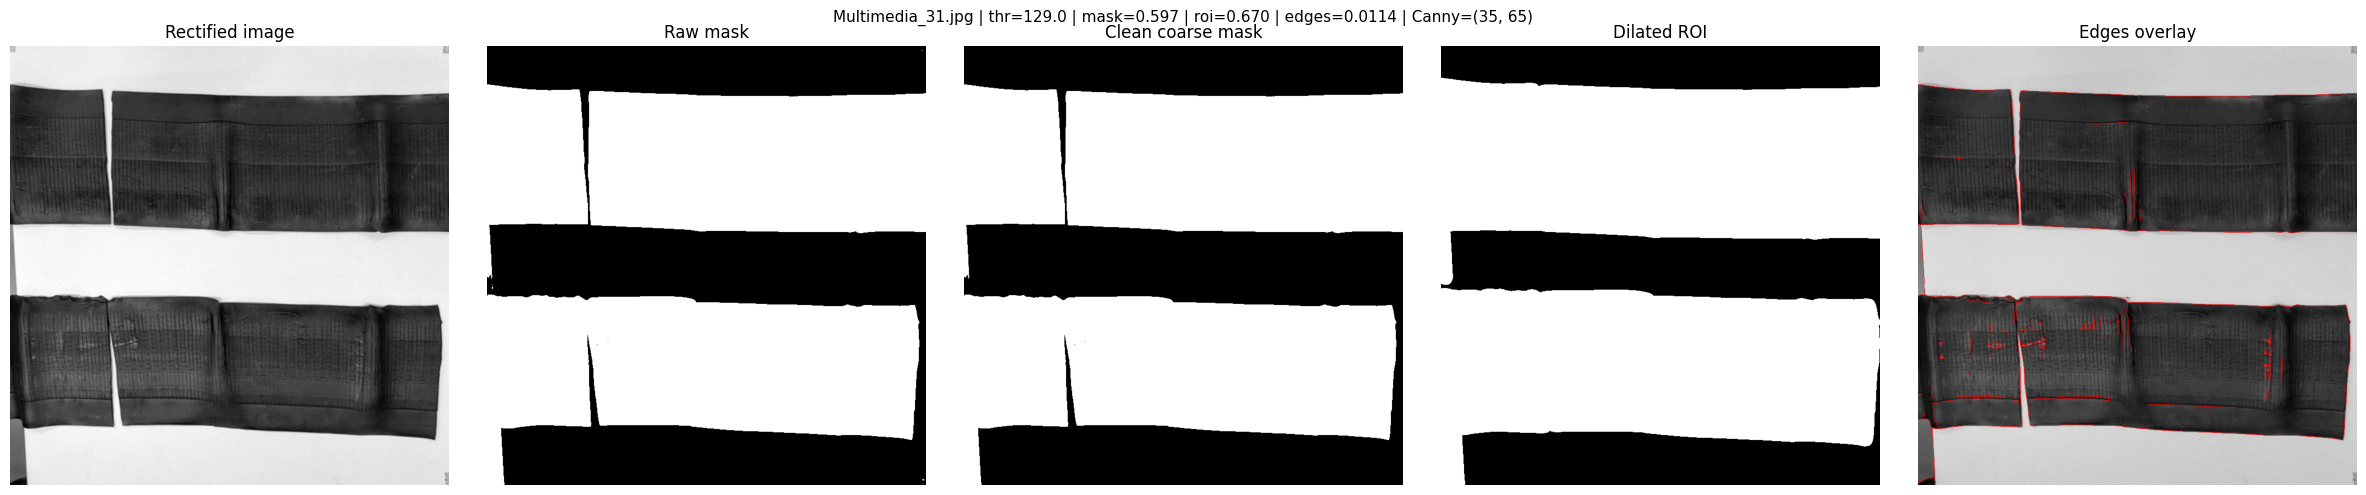

In [10]:
def visualize(image_name: str):
    img_gray = cv2.imread(str(RECTIFIED_DIR / image_name), cv2.IMREAD_GRAYSCALE)
    if img_gray is None:
        print(f"Could not load {image_name}")
        return

    stages = segment_rubber_band_debug(img_gray)
    mask = stages["clean_mask"]
    roi = build_rubber_roi(mask)
    edges, edge_info = detect_edges(mask, img_gray)
    overlay = create_edges_overlay(img_gray, edges)

    fig, axes = plt.subplots(1, 5, figsize=(24, 5))
    fig.suptitle(
        f"{image_name} | thr={stages['threshold']:.1f} | "
        f"mask={np.mean(mask > 0):.3f} | roi={np.mean(roi > 0):.3f} | "
        f"edges={np.mean(edges > 0):.4f} | "
        f"Canny=({edge_info['canny_low']}, {edge_info['canny_high']})",
        fontsize=11,
    )

    axes[0].imshow(img_gray, cmap="gray")
    axes[0].set_title("Rectified image")
    axes[0].axis("off")

    axes[1].imshow(stages["raw_mask"], cmap="gray")
    axes[1].set_title("Raw mask")
    axes[1].axis("off")

    axes[2].imshow(mask, cmap="gray")
    axes[2].set_title("Clean coarse mask")
    axes[2].axis("off")

    axes[3].imshow(roi, cmap="gray")
    axes[3].set_title("Dilated ROI")
    axes[3].axis("off")

    axes[4].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    axes[4].set_title("Edges overlay")
    axes[4].axis("off")

    plt.tight_layout()
    plt.savefig(DIAGNOSTICS_DIR / f"check_{Path(image_name).stem}.png", dpi=130)
    plt.show()


if canny_results:
    visualize(next(iter(canny_results)))

In [11]:
# Visualize a specific image
# visualize("Multimedia_43.jpg")

## 8. Diagnostics across all images

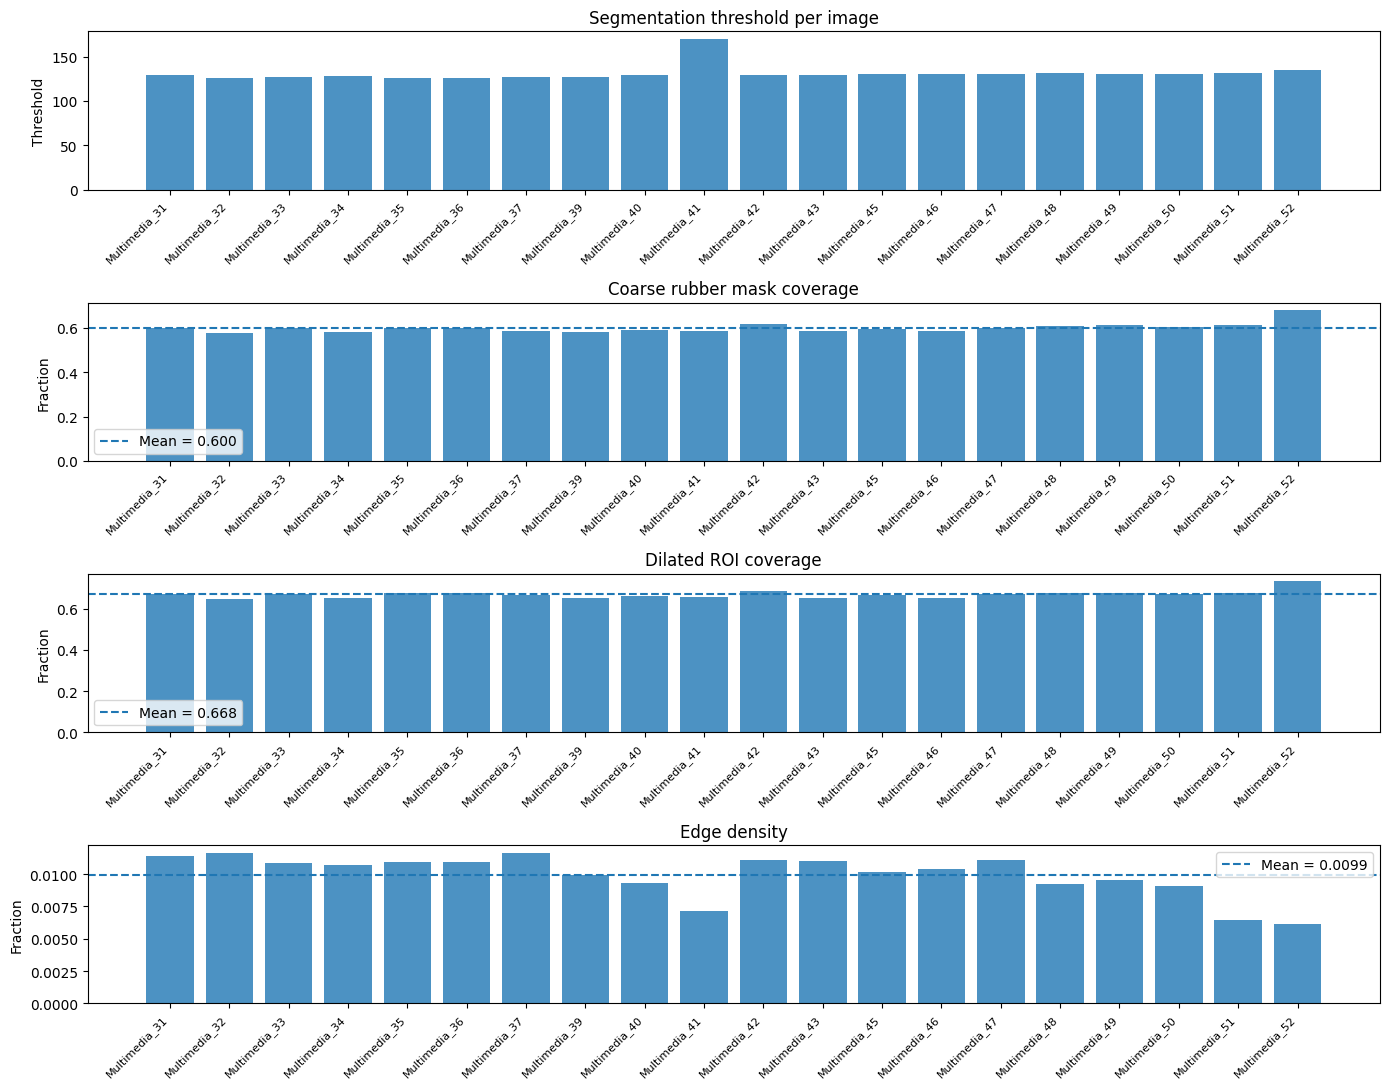

In [12]:
if canny_results:
    names = list(canny_results.keys())
    thrs = [canny_results[n]["threshold"] for n in names]
    mask_coverages = [canny_results[n]["mask_coverage"] for n in names]
    roi_coverages = [canny_results[n]["roi_coverage"] for n in names]
    edge_densities = [canny_results[n]["edge_density"] for n in names]

    x = np.arange(len(names))
    xlabels = [n.replace(".jpg", "") for n in names]

    fig, axes = plt.subplots(4, 1, figsize=(14, 11))

    axes[0].bar(x, thrs, alpha=0.8)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(xlabels, rotation=45, ha="right", fontsize=8)
    axes[0].set_ylabel("Threshold")
    axes[0].set_title("Segmentation threshold per image")

    axes[1].bar(x, mask_coverages, alpha=0.8)
    axes[1].axhline(np.mean(mask_coverages), linestyle="--", label=f"Mean = {np.mean(mask_coverages):.3f}")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(xlabels, rotation=45, ha="right", fontsize=8)
    axes[1].set_ylabel("Fraction")
    axes[1].set_title("Coarse rubber mask coverage")
    axes[1].legend()

    axes[2].bar(x, roi_coverages, alpha=0.8)
    axes[2].axhline(np.mean(roi_coverages), linestyle="--", label=f"Mean = {np.mean(roi_coverages):.3f}")
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(xlabels, rotation=45, ha="right", fontsize=8)
    axes[2].set_ylabel("Fraction")
    axes[2].set_title("Dilated ROI coverage")
    axes[2].legend()

    axes[3].bar(x, edge_densities, alpha=0.8)
    axes[3].axhline(np.mean(edge_densities), linestyle="--", label=f"Mean = {np.mean(edge_densities):.4f}")
    axes[3].set_xticks(x)
    axes[3].set_xticklabels(xlabels, rotation=45, ha="right", fontsize=8)
    axes[3].set_ylabel("Fraction")
    axes[3].set_title("Edge density")
    axes[3].legend()

    plt.tight_layout()
    plt.savefig(DIAGNOSTICS_DIR / "canny_diagnostics.png", dpi=150)
    plt.show()

## 9. Summary

| Step | Operation | Detail |
|------|-----------|--------|
| 3a | Read rectified image | from `outputs/02_rectified_clean/` |
| 3b | Coarse rubber segmentation | Otsu/fixed threshold, inverted: rubber = 255 |
| 3c | Remove small components | removes QR/noise from ROI mask |
| 3d | Build ROI | dilate coarse rubber mask to include borders/gaps |
| 3e | Canny | applied on grayscale image restricted to ROI |

**Main parameters to tune:**

- If there is too much internal rubber texture → increase `GRAY_CANNY_BLUR_KERNEL`, e.g. `(9, 9)`.
- If cut edges disappear → decrease `GRAY_CANNY_BLUR_KERNEL`, e.g. `(5, 5)`.
- If Canny searches too far from the rubber → decrease `ROI_DILATE_KERNEL_SIZE`.
- If cut gaps are outside the ROI → increase `ROI_DILATE_KERNEL_SIZE`.
- If the mask includes QR/noise → increase `MIN_RUBBER_COMPONENT_AREA_RATIO` slightly.

**Output folder:** `outputs/03_canny/`  
**Debug folder:** `outputs/03_canny/debug/`  
**Next notebook:** `04_hough.ipynb` — reads edge maps from `outputs/03_canny/`.